In [43]:
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import colors, cm
from datetime import datetime, timedelta
import util
import scipy.stats as stats

### Data pre processing 

In [44]:
ZH_case = pd.read_csv('data/ZH_case_incidence_data.csv')
ZH_case_selected = ZH_case.rename(columns={'date': 'date_c'})

In [45]:
ZH_ww = pd.read_csv('data/ZH_WW_data.csv')
ZH_case = pd.read_csv('data/ZH_case_incidence_data.csv')
ZH_ww['date'] = pd.to_datetime(ZH_ww['date'])
ZH_case['date'] = pd.to_datetime(ZH_case['date'])
highlight_dates = ['2021-01-10', '2020-12-13', '2021-01-12']
ZH_ww_excluded = ZH_ww[~ZH_ww['date'].isin(highlight_dates)]

start_date = pd.to_datetime('2020-09-03')
end_date = pd.to_datetime('2021-01-19')
future_days = 10                                   
end_date_plus   = end_date + pd.Timedelta(days=future_days)

ZH_ww_selected = ZH_ww_excluded
ZH_case_selected = ZH_case


ZH_case_selected = ZH_case.rename(columns={'date': 'date_c'})
ZH_case_selected = ZH_case_selected.rename(columns={'confirmed': 'noisy_c_values'})
ZH_ww_selected = ZH_ww_excluded.rename(columns={'date': 'date_w'})
ZH_ww_selected = ZH_ww_selected.rename(columns={'n1': 'noisy_w_values'}) # use n1 or n2 or ?


/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_73452/2975194917.py:6: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  ZH_ww_excluded = ZH_ww[~ZH_ww['date'].isin(highlight_dates)]


In [46]:
ref_date = pd.to_datetime('2020-09-01')

ZH_ww_selected = ZH_ww_selected[
    (ZH_ww_selected['date_w'] >= start_date) & (ZH_ww_selected['date_w'] <= end_date)
]
ZH_case_future = ZH_case_selected[
    (ZH_case_selected['date_c'] >= start_date) & (ZH_case_selected['date_c'] <= end_date_plus)
]
ZH_case_selected = ZH_case_selected[
    (ZH_case_selected['date_c'] >= start_date) & (ZH_case_selected['date_c'] <= end_date)
]

ZH_ww_selected['dayofweek'] = ZH_ww_selected['date_w'].dt.dayofweek + 1
ZH_case_selected['dayofweek'] = ZH_case_selected['date_c'].dt.dayofweek + 1
ZH_case_future['dayofweek'] = ZH_case_future['date_c'].dt.dayofweek + 1

ZH_ww_selected['date_w'] = (ZH_ww_selected['date_w'] - ref_date).dt.days
ZH_case_selected['date_c'] = (ZH_case_selected['date_c'] - ref_date).dt.days
ZH_case_future['date_c'] = (ZH_case_future['date_c'] - ref_date).dt.days

case_empt = pd.DataFrame(columns=["date_c", "noisy_c_values"])
ww_empt = pd.DataFrame(columns=["date_w", "noisy_w_values"])

In [33]:
ZH_ww_selected.to_csv("data/ZH_ww_selected.csv", index=False)
ZH_case_selected.to_csv("data/ZH_case_selected.csv",   index=False)
case_empt.to_csv("data/case_empt.csv", index=False)
ww_empt.to_csv("data/ww_empt.csv",   index=False)

In [47]:
weekend_factors = []

for t_idx in range(1, len(ZH_case_selected) - 2):  # Loop from Friday to Monday
    # Extract the day of the week for each date
    friday_row = ZH_case_selected.iloc[t_idx - 1]  # Friday
    saturday_row = ZH_case_selected.iloc[t_idx]   # Saturday
    sunday_row = ZH_case_selected.iloc[t_idx + 1]  # Sunday
    monday_row = ZH_case_selected.iloc[t_idx + 2]  # Monday
    
    # Ensure the day of the week matches the expected days
    if friday_row['dayofweek'] == 5 and saturday_row['dayofweek'] == 6 and sunday_row['dayofweek'] == 7 and monday_row['dayofweek'] == 1:
        
        friday_incidence = friday_row['noisy_c_values']
        saturday_incidence = saturday_row['noisy_c_values']
        sunday_incidence = sunday_row['noisy_c_values']
        monday_incidence = monday_row['noisy_c_values']
        
        weekend_incidence = (saturday_incidence + sunday_incidence) / 2
        weekday_incidence = (friday_incidence + monday_incidence) / 2
        
        # Calculate f for this series (weekend / weekday)
        if weekday_incidence > 0:
            f = weekend_incidence / weekday_incidence
            weekend_factors.append(f)

med_w_diff = np.median(weekend_factors)
print (med_w_diff)

0.5331378423747901


In [48]:
n = 40 # Number of compartments
n_particles = 1000
c_i = util.generate_neg_binom(n, 11.528428093645484, 0.8) # Case detection profile
omega_i = util.generate_neg_binom(n, 3.1515151515151514, 0.24444444444444444) # Shedding load profile
f_i= util.generate_neg_binom(n, 3.8989898989898992, 0.4473684210526315) # Infectivity profile 
dt_real = 0.1


### Figure 7

In [50]:
def get_logL_ZH_enfout(Casedata, WWdata, n_particles, epiparams, burnin_point = 0):
    ref_date = datetime(2020, 9, 1)
    Re_curr = np.random.lognormal(mean=0.0, sigma=0.5, size=(n_particles, 1))
    mu, sigma = 2.5, 1.0
    log10_I_init = np.random.normal(loc=mu, scale=sigma, size=n_particles)
    I_init_total = 10**log10_I_init
    I_curr = np.zeros((n_particles, n))
    I_curr[:, 0] = I_init_total

    Sc_curr = np.zeros(n_particles)
    Sw_curr = np.zeros(n_particles)

    # Initialize storage for simulation results
    Re, w_list, wmean = [], [], []
    cumulative_incidence_record, wastewater_concentration_record, I_record = [], [], []

    # Determine the number of time points
    n_timepts = len(epiparams["tList"])
    t_day = []              # times when resampling occurs
    
    ancestry = np.empty((n_timepts, n_particles), dtype=int)
    ancestry[:, :] = np.arange(n_particles)  # initial ancestry

    for t_idx in range(n_timepts - 1):
        current_dt = ref_date + timedelta(days=epiparams["tList"][t_idx])
        wd = current_dt.weekday() + 1  
        if wd <= 5:  
            rho_t = epiparams["rho"]         # Mon–Fri
        else:
            rho_t = med_w_diff * epiparams["rho"] 

        # Brownian motion update for Re
        dRe = epiparams["sigma_Re"] * np.random.randn(n_particles, 1) * dt_real
        Re_curr = Re_curr + dRe  
        Re_curr = np.clip(Re_curr, 0, 30)
        
        dt = epiparams["tList"][t_idx + 1] - epiparams["tList"][t_idx]
        dI = np.zeros_like(I_curr)
        dSc = np.zeros(n_particles)
        dSw = np.zeros(n_particles)
        dSw_nout = np.zeros(n_particles)
        # Force of infection
        Psi = epiparams["n"] * epiparams["nu"] * Re_curr.flatten() * (I_curr[:, :epiparams["n"]] @ f_i)
        
        # Infection compartment dynamics
        dI[:, 0] = Psi - epiparams["n"] * epiparams["nu"] * I_curr[:, 0]
        dI[:, 1:epiparams["n"]-1] = -epiparams["n"] * epiparams["nu"] * I_curr[:, 1:epiparams["n"]-1] + epiparams["n"] * epiparams["nu"] * I_curr[:, :epiparams["n"]-2]
        dI[:, epiparams["n"]-1] = epiparams["n"] * epiparams["nu"] * I_curr[:, epiparams["n"]-2]
        
        
        # Cumulative incidence dynamics
        dSc = epiparams["n"] * epiparams["nu"] * rho_t * (I_curr[:, :epiparams["n"]] @ c_i)
        # Wastewater dynamics
        dSw_nout = epiparams["eps_ww_out"] * epiparams["delta_ww"] * Sw_curr * np.random.randn(n_particles)
        dSw = epiparams["lambda_ww"] * (I_curr[:, :epiparams["n"]] @ omega_i) - epiparams["delta_ww"] * Sw_curr
        
        # Update the state vector using the Euler-Maruyama method
        I_curr[:, :epiparams["n"]] += dI[:, :epiparams["n"]] * dt
        Sc_curr += dSc * dt
        Sw_curr += dSw * dt + dSw_nout * dt
        
        # Record simulation results
        cumulative_incidence_record.append(Sc_curr.copy())
        wastewater_concentration_record.append(Sw_curr.copy())
        I_record.append(I_curr.copy())
        Re.append(Re_curr.copy())
        
        date_c_list = Casedata["date_c"].tolist()
        date_w_list = WWdata["date_w"].tolist()
        joint_list = sorted(list(set(date_c_list) | set(date_w_list)))
    
        # Determine the current simulation time for potential observation
        compare_time = epiparams["tList"][t_idx + 1]

        if compare_time in joint_list:
            k_vector = np.arange(n_particles) 
            likelihoods = np.ones(n_particles)

            if compare_time in date_w_list:
                # Retrieve the current wastewater concentration (flatten if needed)
                Sw_curr_flat = np.array(Sw_curr).flatten()
                obsWW = WWdata["noisy_w_values"][WWdata["date_w"] == compare_time]
                # Compute the gamma likelihood for the wastewater data

                likelihoods_ww = stats.gamma.pdf(
                    obsWW,
                    a=(Sw_curr_flat / epiparams["std_ww"]) ** 2,  # shape k
                    scale=(epiparams["std_ww"] ** 2) / Sw_curr_flat  # scale θ
                )

                likelihoods_ww = np.ravel(likelihoods_ww)
                likelihoods *= likelihoods_ww 

            if compare_time in date_c_list:
                # Ensure that we have enough recorded steps (at least 7 days worth)
                steps_back = int(1 / dt_real) # up to changes
                if len(cumulative_incidence_record) > steps_back:
                    current_idx = len(cumulative_incidence_record) - 1  # current time index
                    week_idx = current_idx - steps_back             # index 7 days ago
                    weekly_incidence = np.zeros(n_particles)
                    
                    # Trace the ancestry for each particle to pick the correct cumulative incidence from 7 days ago
                    for particle in range(n_particles):
                        anc = particle
                        # Trace ancestry from the current time back to week_idx
                        for t in range(current_idx, week_idx, -1):
                            anc = ancestry[t, anc]
                        # Calculate weekly incidence along the same ancestral path
                        weekly_incidence[particle] = cumulative_incidence_record[current_idx][particle] - cumulative_incidence_record[week_idx][anc]
                else:
                    # If not enough time points have been recorded, use the current cumulative incidence
                    weekly_incidence = cumulative_incidence_record[-1]

                # Ensure weekly_incidence is a 1D numpy array of shape (n_particles,)
                weekly_incidence = np.array(weekly_incidence).flatten()
                
                # Retrieve the observed case(s) for this time point
                obsCase = Casedata["noisy_c_values"][Casedata["date_c"] == compare_time]
                
                # Compute likelihoods using the negative binomial PMF
                likelihoods_case = stats.nbinom.pmf(
                    obsCase,
                    epiparams["k_overdispersion_case"],
                    epiparams["k_overdispersion_case"] / (epiparams["k_overdispersion_case"] + weekly_incidence)
                )

                # Ensure likelihoods is a 1D array
                likelihoods_case = np.ravel(likelihoods_case)
                likelihoods *= likelihoods_case 

            if (not np.all(np.isfinite(likelihoods))) or np.any(likelihoods < 0):
                raise util.ModelNumericsError("Invalid combined likelihood.")

            # Resample 
            k_vector = util.resample_particles_multinomial(likelihoods, n_particles)
            ancestry[t_idx + 1, :] = k_vector
            I_curr = I_curr[k_vector, :]
            Sc_curr = Sc_curr[k_vector]
            Sw_curr = Sw_curr[k_vector]
            Re_curr = Re_curr[k_vector]
            t_day.append(compare_time)
            w_list.append(likelihoods)
            wmean.append(np.mean(likelihoods))

    t_day_arr = np.asarray(t_day)
    wmean_arr = np.asarray(wmean)

    keep_mask = t_day_arr >= burnin_point       # True → keep
    safe_w    = np.maximum(wmean_arr[keep_mask],
                           np.finfo(float).tiny)

    theta_logL = np.sum(np.log(safe_w))
    
    final_particle = np.random.randint(n_particles)
    trajectory_indices = [final_particle]
    for t in range(n_timepts - 1, 0, -1):
        final_particle = ancestry[t, final_particle]
        trajectory_indices.insert(0, final_particle)
    
    recon = {
        "Re": np.array([Re[t][trajectory_indices[t]] for t in range(len(Re))]),
        "t_day": np.array(t_day),
        "t": epiparams["tList"][1:],
        "I_record": np.array([I_record[t][trajectory_indices[t], :] for t in range(len(I_record))]),
        "Cumulative": np.array([cumulative_incidence_record[t][trajectory_indices[t]] for t in range(len(cumulative_incidence_record))]),
        "WW_concentration": np.array([wastewater_concentration_record[t][trajectory_indices[t]] for t in range(len(wastewater_concentration_record))])
    }

    w_incidence = util.calculate_weekly_incidence(recon["Cumulative"])
    d_incidence = util.calculate_daily_incidence(recon["Cumulative"])
    sub_t  = np.arange(0, 140, dt_real)
    weekly_time = sub_t[70::70]
    recon["w_incidence"] = w_incidence
    recon["weekly_time"] = weekly_time
    recon["d_incidence"] = d_incidence
    recon["daily_time"] = sub_t[10::10] -1
    recon["ess_values"] = [len(np.unique(ancestry[t, :])) for t in range(n_timepts)]
    recon["wmean"] = wmean
    return theta_logL, recon

#### Case only 

In [ ]:
epiparams = {
    "n": 40,  # Number of compartments
    "sigma_Re": 0.6,  # Initial standard deviation for Brownian motion
    "lambda_ww": 2.02e10,  # Shedding load scaling constant
    "delta_ww":1, # Decay rate of viral load in wastewater
    # "sigma_ww": 3e12,  # Measurement noise in wastewater 
    "std_ww":2e12, # Std in ww
    "k_overdispersion_case" : 10, # Overdispersion parameter for weekly incidence 
    "eps_ww_out": 0,  # Environmental noise factor 
    "nu": 1/40,  # Transition rate                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         
    "dt": dt_real,  # Time step
    "time_start_day": 0,  # Start day
    "time_end_day": 140,  # End day
    "tList": np.arange(0, 140, dt_real), #
    "rho": 0.3 # Reporting rate (fraction of actual infections reported)
}

rho_value = [0.10, 0.14, 0.18, 0.22, 0.26, 0.30, 0.34, 0.38, 0.42, 0.46, 0.50, 0.54, 0.58, 0.62, 0.66, 0.70, 0.74, 0.78, 0.82, 0.86, 0.90, 0.94, 0.95]
sigma_Re_value = np.round(np.arange(0.20, 0.90 + 0.001, 0.02), 2).tolist()

n_repl    = 10   
   
logL_all_case  = np.empty((len(sigma_Re_value), len(rho_value), n_repl))
mean_ll_array_case = np.empty((len(sigma_Re_value), len(rho_value)))  
median_ll_array_case = np.empty((len(sigma_Re_value), len(rho_value)))  

for i, sigma in enumerate(sigma_Re_value):
    epiparams["sigma_Re"] = sigma
    for j, rho in enumerate(rho_value):
        epiparams["rho"] = rho
        for r in range(n_repl):
            theta_logL, recon = get_logL_ZH_enfout(ZH_case_selected, ww_empt, n_particles, epiparams, burnin_point=18)
            logL_all_case[i, j, r] = theta_logL     
        mean_ll_array_case[i, j] = logL_all_case[i, j].mean()
        median_ll_array_case[i, j] = np.median(logL_all_case[i, j])


# np.save("mean_logL_ZH_case_10000.npy", mean_ll_array_case)
# np.save("logL_all_ZH_case_10000.npy", logL_all_case)



In [52]:
# Case only 
rho_value = [0.10, 0.14, 0.18, 0.22, 0.26, 0.30, 0.34, 0.38, 0.42, 0.46, 0.50, 0.54, 0.58, 0.62, 0.66, 0.70, 0.74, 0.78, 0.82, 0.86, 0.90, 0.94, 0.95]
sigma_Re_value = np.round(np.arange(0.20, 0.90 + 0.001, 0.02), 2).tolist()

logL_all_case = np.load('ZH_results/logL_all_ZH_case.npy')
median_matrix = util.analyze_median(logL_all_case, sigma_Re_value, rho_value, n_repl=10)
median_matrix[median_matrix < -705] = -705
np.random.seed(46)

recon_dict_case = {}

combinations = [
    (0.2, 0.32),  # combination 1
    (0.8, 0.32)   # combination 2
]

for (this_rho, this_sigma) in combinations:
    epiparams["rho"] = this_rho
    epiparams["sigma_Re"] = this_sigma
    theta_logL, recon = get_logL_ZH_enfout(ZH_case_selected, ww_empt, n_particles, epiparams, burnin_point=18)
    recon_dict_case[(this_rho, this_sigma)] = recon

#### Wastewater without environmental noise 

In [ ]:
# ww without envrionmental noise 

lambda_value = np.geomspace(1e9, 1e11, num=50)
sigma_Re_value = np.round(np.arange(0.20, 1.9 + 0.0001, 0.06), 3).tolist()

epiparams = {
    "n" : 40, # Number of compartments
    "sigma_Re": 1.76,  # Initial standard deviation for Brownian motion
    "lambda_ww": 32374575428.1764,  # Shedding load scaling constant
    "delta_ww":1, # Decay rate of viral load in wastewater
    "std_ww":2.2114e12, # Std in ww 
    "k_overdispersion_case" : 10, # Overdispersion parameter for weekly incidence 
    "eps_ww_out": 0,  # Environmental noise factor 
    "nu": 1/40,  # Transition rate 1 per day                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
    "dt": dt_real,  # Time step
    "time_start_day": 0,  # Start day
    "time_end_day": 140,  # End day
    "tList": np.arange(0, 140, dt_real), #
    "rho": 0.3 # Reporting rate (fraction of actual infections reported)
}

logL_all_ww = np.full((len(sigma_Re_value), len(lambda_value), n_repl), np.nan)
mean_ll_array_ww = np.full((len(sigma_Re_value), len(lambda_value)), np.nan) 
medianll_array_ww = np.full((len(sigma_Re_value), len(lambda_value)), np.nan) 

for i, sigma in enumerate(sigma_Re_value):
    epiparams["sigma_Re"] = sigma
    for j, lambdaa in enumerate(lambda_value):
        epiparams["lambda_ww"] = lambdaa
        for r in range(n_repl):
            try:
                theta_logL, recon = get_logL_ZH_enfout(
                    case_empt, ZH_ww_selected, n_particles, epiparams, burnin_point=18
                )
                if np.isfinite(theta_logL):
                    logL_all_ww[i, j, r] = theta_logL
            except util.ModelNumericsError:
                # skip this replicate
                continue
            except KeyboardInterrupt:
                raise
            except Exception as e:
                # unexpected error — skip (optionally log e)
                continue

        cell_vals = logL_all_ww[i, j, :]
        if np.all(np.isnan(cell_vals)):
            mean_ll_array_ww[i, j]   = -np.inf
            medianll_array_ww[i, j]  = -np.inf
        else:
            mean_ll_array_ww[i, j]   = np.nanmean(cell_vals)
            medianll_array_ww[i, j]  = np.nanmedian(cell_vals)

#np.save("mean_logL_ZH_out_ww_noen.npy", mean_ll_array_ww)
#np.save("median_logL_ZH_out_wwnoen.npy", medianll_array_ww)
#np.save("logL_all_ZH_out_wwnoen.npy", logL_all_ww)


In [54]:
median_ll_array_ww_replot = np.load('ZH_results/median_logL_ZH_out_wwnoen.npy')
median_ll_array_ww_replot[median_ll_array_ww_replot < -2600] = -2600
np.random.seed(49)

recon_dict_ww_noen = {}
combinations = [
(12067926406,1.76 ),
(75431200633,1.76 )
]
for (this_lambda, this_sigma) in combinations:
    epiparams["lambda_ww"] = this_lambda
    epiparams["sigma_Re"] = this_sigma
    theta_logL, recon = get_logL_ZH_enfout(case_empt, ZH_ww_selected, n_particles, epiparams, burnin_point=18)
    recon_dict_ww_noen[(this_lambda, this_sigma)] = recon

#### Wastewater with environmental noise 

In [ ]:
# WW with env noise 
eps_ww_out = np.round(np.arange(0.50, 2.9 + 0.001, 0.05), 2).tolist()
sigma_Re_value = np.round(np.arange(0.20, 1.9 + 0.0001, 0.06), 3).tolist()

epiparams = {
    "n" : 40, # Number of compartments
    "sigma_Re": 0.32,  # Initial standard deviation for Brownian motion
    "lambda_ww": 2.02e10,  # Shedding load scaling constant
    "delta_ww":1, # Decay rate of viral load in wastewater
    # "sigma_ww": 3e12,  # Measurement noise in wastewater 
    "std_ww":2.2114e12, # Std in ww
    "k_overdispersion_case" : 10, # Overdispersion parameter for weekly incidence 
    "eps_ww_out": 0.95,  # Environmental noise factor 
    "nu": 1/40,  # Transition rate 1 per day                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
    "dt": dt_real,  # Time step
    "time_start_day": 0,  # Start day
    "time_end_day": 140,  # End day
    "tList": np.arange(0, 140, dt_real), #
    "rho": 0.3 # Reporting rate (fraction of actual infections reported)
}

logL_all_ww = np.full((len(sigma_Re_value), len(eps_ww_out), n_repl), np.nan)
mean_ll_array_ww = np.full((len(sigma_Re_value), len(eps_ww_out)), np.nan) 
medianll_array_ww = np.full((len(sigma_Re_value), len(eps_ww_out)), np.nan) 

for i, sigma in enumerate(sigma_Re_value):
    epiparams["sigma_Re"] = sigma
    for j, eps in enumerate(eps_ww_out):
        epiparams["eps_ww_out"] = eps
        for r in range(n_repl):
            try:
                theta_logL, recon = get_logL_ZH_enfout(
                    case_empt, ZH_ww_selected, n_particles, epiparams, burnin_point=18
                )
                if np.isfinite(theta_logL):
                    logL_all_ww[i, j, r] = theta_logL
            except util.ModelNumericsError:
                # skip this replicate
                continue
            except KeyboardInterrupt:
                raise
            except Exception as e:
                # unexpected error — skip (optionally log e)
                continue

        cell_vals = logL_all_ww[i, j, :]
        if np.all(np.isnan(cell_vals)):
            mean_ll_array_ww[i, j]   = -np.inf
            medianll_array_ww[i, j]  = -np.inf
        else:
            mean_ll_array_ww[i, j]   = np.nanmean(cell_vals)
            medianll_array_ww[i, j]  = np.nanmedian(cell_vals)

#np.save("mean_logL_ZH_out_ww_std2e12.npy", mean_ll_array_ww)
#np.save("median_logL_ZH_out_ww_std2e12.npy", medianll_array_ww)
#np.save("logL_all_ZH_out_ww_std2e12.npy", logL_all_ww)
    

In [56]:
median_ll_array_ww_replot = np.load('ZH_results/median_logL_ZH_out_ww_std2e12.npy')
median_ll_array_ww_replot[median_ll_array_ww_replot < -2490] = -2490

np.random.seed(46)
recon_dict_ww_en = {}

combinations = [
(0.95,0.32 )
]
for (this_eps, this_sigma) in combinations:
    epiparams["eps_ww_out"] = this_eps
    epiparams["sigma_Re"] = this_sigma
    theta_logL, recon = get_logL_ZH_enfout(case_empt, ZH_ww_selected, n_particles, epiparams, burnin_point=18)
    recon_dict_ww_en[(this_eps, this_sigma)] = recon
    

#### Both case and wastewater 

In [ ]:
lambda_value = np.geomspace(1e10, 1e12, num=50)
rho_value    = np.linspace(0.05, 0.6, 18)

epiparams = {
    "n" : 40, # Number of compartments
    "sigma_Re": 0.32,  # Initial standard deviation for Brownian motion
    "lambda_ww": 13257113655.901108,  # Shedding load scaling constant
    "delta_ww":1, # Decay rate of viral load in wastewater
    "std_ww":2e12, # Sd in ww
    "k_overdispersion_case" : 10, # Overdispersion parameter for weekly incidence 
    "eps_ww_out": 0.95,  # Environmental noise factor 
    "nu": 1/40,  # Transition rate 1 per day                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
    "dt": dt_real,  # Time step
    "time_start_day": 0,  # Start day
    "time_end_day": 140,  # End day
    "tList": np.arange(0, 140, dt_real), #
    "rho": 0.11470588235294117 # Reporting rate (fraction of actual infections reported)
}

logL_all_both = np.full((len(lambda_value), len(rho_value), n_repl), np.nan)
mean_ll_array_both = np.full((len(lambda_value), len(rho_value)), np.nan) 
medianll_array_both = np.full((len(lambda_value), len(rho_value)), np.nan) 

for i, lambdaw in enumerate(lambda_value):
    epiparams["lambda_ww"] = lambdaw
    for j, rho in enumerate(rho_value):
        epiparams["rho"] = rho
        for r in range(n_repl):
            try:
                theta_logL, recon = get_logL_ZH_enfout(
                    ZH_case_selected, ZH_ww_selected, n_particles, epiparams, burnin_point=18
                )
                if np.isfinite(theta_logL):
                    logL_all_both[i, j, r] = theta_logL
            except util.ModelNumericsError:
                # skip this replicate
                continue
            except KeyboardInterrupt:
                raise
            except Exception as e:
                # unexpected error — skip (optionally log e)
                continue

        cell_vals = logL_all_both[i, j, :]
        if np.all(np.isnan(cell_vals)):
            mean_ll_array_both[i, j]   = -np.inf
            medianll_array_both[i, j]  = -np.inf
        else:
            mean_ll_array_both[i, j]   = np.nanmean(cell_vals)
            medianll_array_both[i, j]  = np.nanmedian(cell_vals)

#np.save("mean_logL_ZH_out_both.npy", mean_ll_array_both)
#np.save("median_logL_ZH_out_both.npy", medianll_array_both)
#np.save("logL_all_ZH_out_both.npy", logL_all_both)


In [58]:
median_ll_array_both_replot = np.load('ZH_results/median_logL_ZH_out_both.npy')
median_ll_array_both_replot[median_ll_array_both_replot < -3800] = -3800

np.random.seed(46)
combinations = [
(3.72759372e+10, 0.34117647),
(65512855685,0.5676470588235294)
]

recon_dict_both = {}

for (this_lambda, this_rho) in combinations:
    epiparams["lambda_ww"] = this_lambda
    epiparams["rho"] = this_rho
    theta_logL, recon = get_logL_ZH_enfout(case_empt, ZH_ww_selected, n_particles, epiparams, burnin_point=18)
    recon_dict_both[(this_lambda, this_rho)] = recon

#### Final plot

In [59]:
def days_to_dates(day_vec, ref_date):
    """
    Convert an array/Series of 'days since ref_date' -> numpy array of datetimes.
    """
    if hasattr(day_vec, "to_numpy"):   # pandas Series
        day_vec = day_vec.to_numpy()
    day_vec = np.asarray(day_vec, dtype=float).ravel()
    return np.array([ref_date + timedelta(days=float(d)) for d in day_vec])

# For consistent formatting across all date-x panels
date_locator   = mdates.AutoDateLocator()
date_formatter = mdates.DateFormatter("%Y-%m-%d")

def format_date_axis(ax):
    ax.xaxis.set_major_locator(date_locator)
    ax.xaxis.set_major_formatter(date_formatter)

    for lbl in ax.get_xticklabels():
        lbl.set_rotation(25)
        lbl.set_ha("right")

shade_start = ref_date
shade_end   = ref_date + timedelta(days=18)

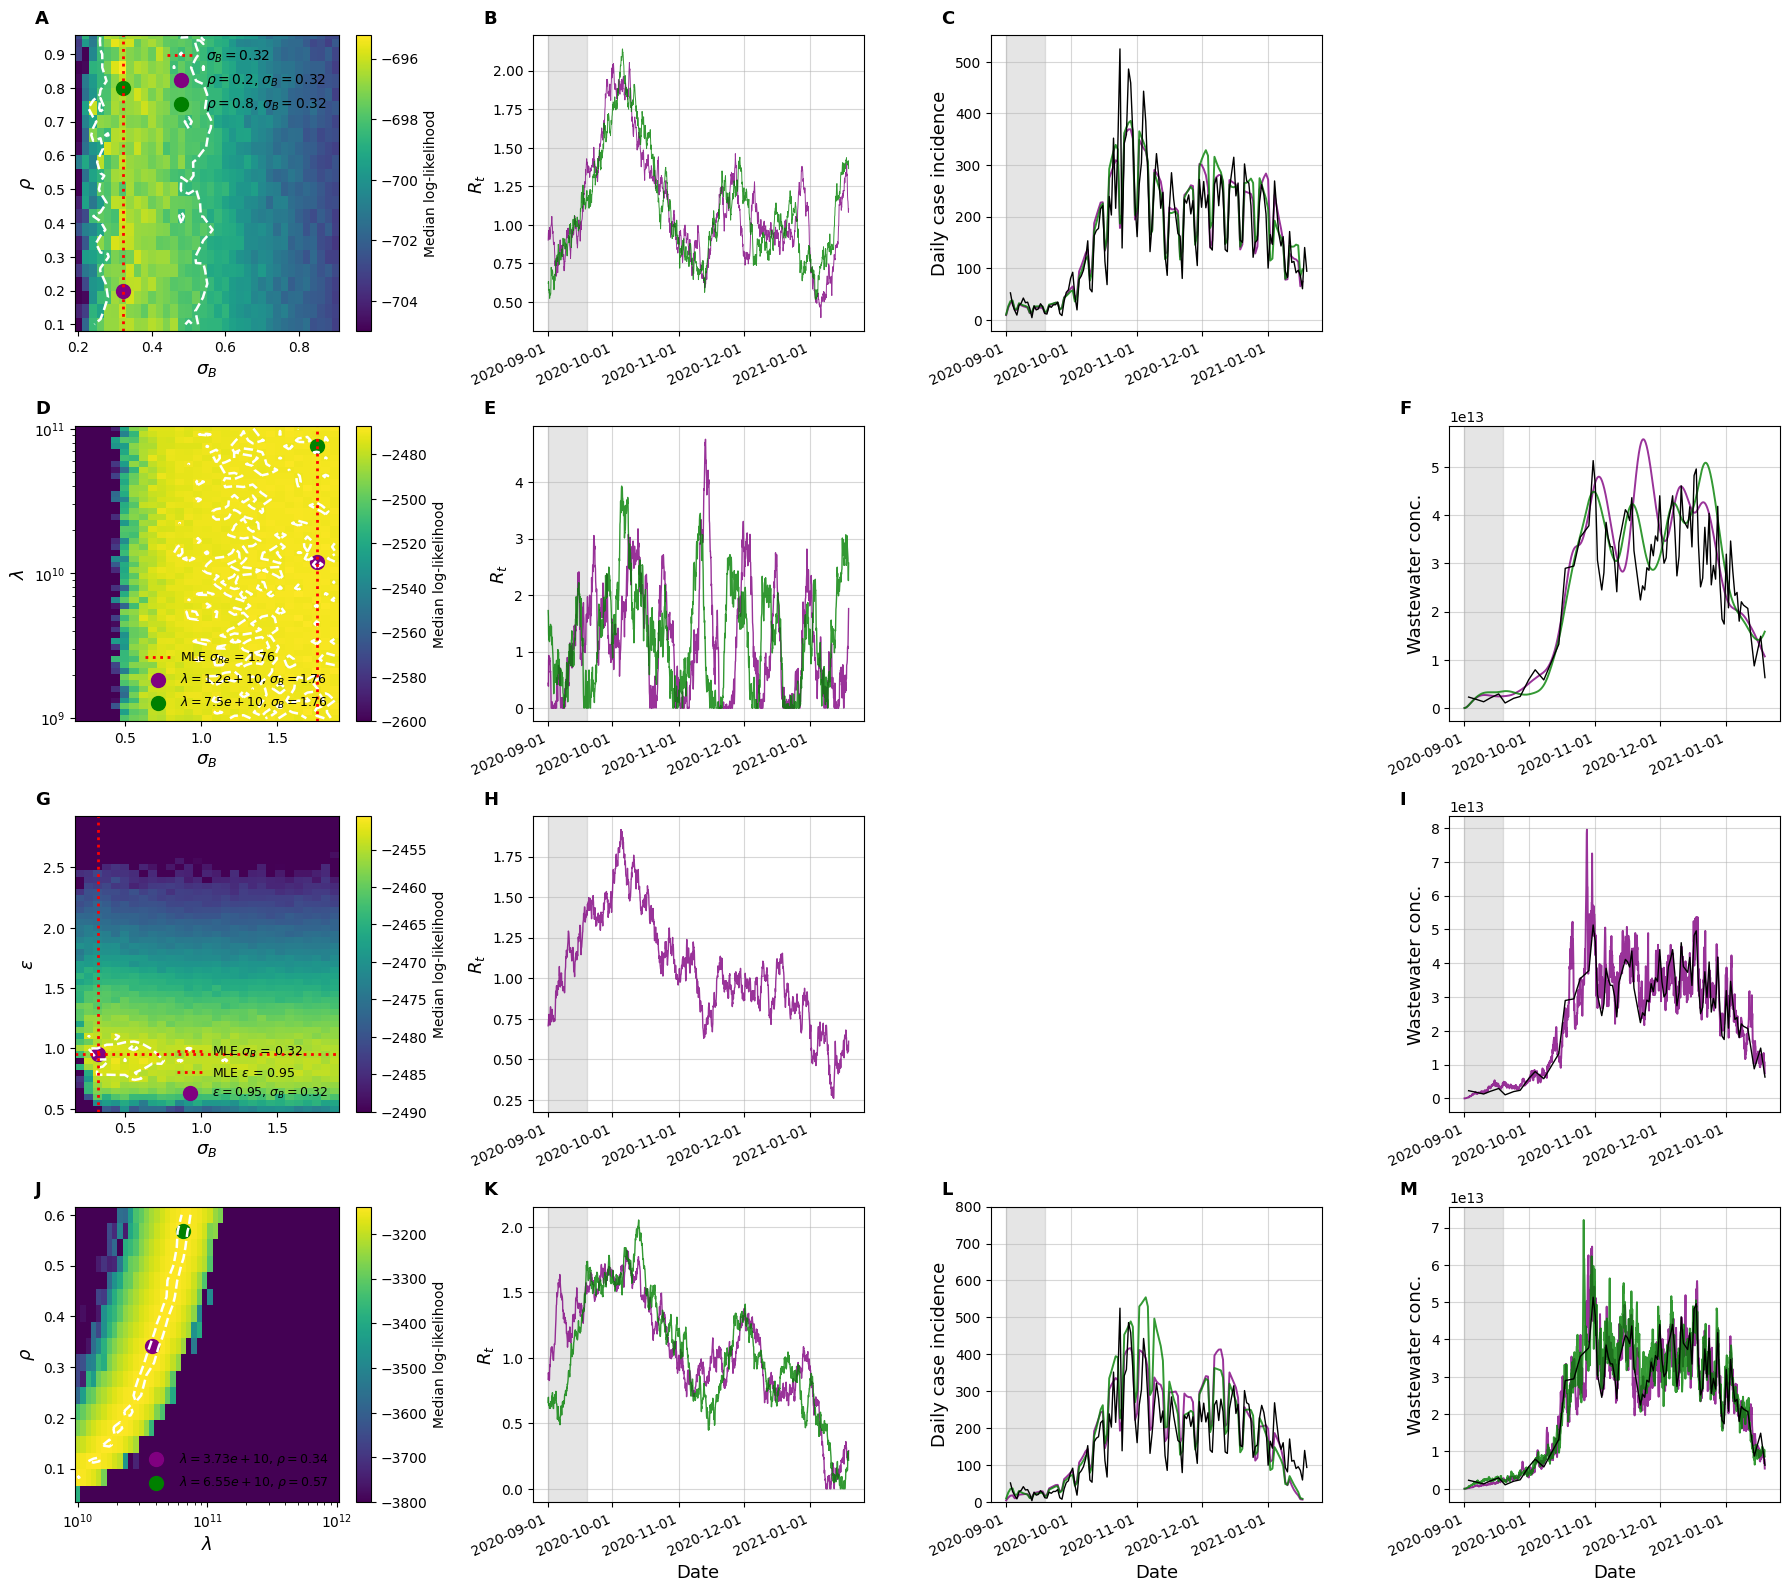

In [60]:
# ----------------------------------------------
# 0.  Set-up
# ----------------------------------------------
label_font = {'fontsize': 13}

fig, axs = plt.subplots(
    4, 4, figsize=(18, 16),              
    constrained_layout=False       
)
plt.subplots_adjust(wspace=.35, hspace=.40)
ax_flat = axs.flatten()
axA, axB, axC, ax_empty1   = axs[0]               
axD, axE, ax_empty2, axF   = axs[1] 
axG, axH, ax_empty3, axI   = axs[2]
axJ, axK, axL, axM         = axs[3]                 

# --------------------------------------------------
# 1.  FIRST-FIGURE PANELS  (A, B, C)
# --------------------------------------------------
color_map = {(0.2, 0.32): 'purple',
             (0.8, 0.32): 'green'}

# --- Panel A  (σRe vs ρ log-likelihood heat-map) ---

rho_value = [0.10, 0.14, 0.18, 0.22, 0.26, 0.30, 0.34, 0.38, 0.42, 0.46, 0.50, 0.54, 0.58, 0.62, 0.66, 0.70, 0.74, 0.78, 0.82, 0.86, 0.90, 0.94, 0.95]
sigma_Re_value = np.round(np.arange(0.20, 0.90 + 0.001, 0.02), 2).tolist()
median_matrix[median_matrix < -705] = -705

SigmaGrid, RhoGrid = np.meshgrid(sigma_Re_value, rho_value)
heat = axA.pcolormesh(SigmaGrid, RhoGrid, median_matrix.T,
                      cmap='viridis', shading='auto')
fig.colorbar(heat, ax=axA, label='Median log-likelihood')

Lmax         = median_matrix.max()
threshold_95 = Lmax - 2.996

cs = axA.contour(SigmaGrid, RhoGrid, median_matrix.T,
                 levels=[threshold_95], colors="white", linestyles="--",
                 linewidths=1.8)

i_max, j_max = np.unravel_index(np.argmax(median_matrix.T),
                                median_matrix.T.shape)
mle_sigma = sigma_Re_value[j_max]
axA.axvline(mle_sigma, ls=':', lw=2, color='red',
            label=fr'$σ_{{B}}={mle_sigma:.3g}$')

for (ρ, σ), col in color_map.items():
    axA.scatter(σ, ρ, s=100, color=col,
                label=fr'$ρ={ρ}$, $σ_{{B}}={σ}$')

axA.set_xlabel(r'$σ_{B}$', **label_font)
axA.set_ylabel(r'$ρ$',        **label_font)
axA.text(-0.15, 1.04, 'A', transform=axA.transAxes,
         **label_font, fontweight="bold")

axA.legend(framealpha=0)

# --- Panel B  (reconstructed R_t) ---
for (ρ, σ), recon in recon_dict_case.items():
    x_t = days_to_dates(recon["t"], ref_date)
    axB.plot(x_t, recon['Re'],
             color=color_map[(ρ, σ)], lw=.7, alpha=.8,
             label=fr'$ρ={ρ}$, $σ_{{B}}={σ}$')
axB.axvspan(shade_start, shade_end, color='grey', alpha=0.2)
# axB.set_xlabel('Date', **label_font)
axB.set_ylabel(r'$R_t$', **label_font)
format_date_axis(axB)
axB.text(-0.15, 1.04, 'B', transform=axB.transAxes,
         **label_font, fontweight="bold")

axB.grid(alpha=.5)
# axB.legend(framealpha=0)


# --- Panel C  (Daily case incidence) ---
for (ρ, σ), recon in recon_dict_case.items():
    x_d = days_to_dates(recon["daily_time"], ref_date)
    axC.plot(x_d, recon["d_incidence"],
             color=color_map[(ρ, σ)], lw=1.4, alpha=.8,
             label=fr'$ρ={ρ}$, $σ_{{B}}={σ}$')
    


x_obs_c = days_to_dates(ZH_case_selected["date_c"], ref_date)
axC.plot(x_obs_c, ZH_case_selected["noisy_c_values"],
         color='black', lw=1, label='True Daily Incidence')

axC.axvspan(shade_start, shade_end, color='grey', alpha=0.2)
# axC.set_xlabel("Date", **label_font)
format_date_axis(axC)
axC.set_ylabel('Daily case incidence', **label_font)
axC.text(-0.15, 1.04, 'C', transform=axC.transAxes,
         **label_font, fontweight="bold")
axC.grid(alpha=.5)
# axC.legend(loc='upper right', framealpha=0)

# --------------------------------------------------
# 2.  SECOND-FIGURE PANELS  (D, E, F)
# --------------------------------------------------
color_map = {(12067926406,1.76 ): 'purple',
             (75431200633,1.76 ): 'green'} 

lambda_value = np.geomspace(1e9, 1e11, num=50)
sigma_Re_value = np.round(np.arange(0.20, 1.9 + 0.0001, 0.06), 3).tolist()

median_ll_array_ww_replot = np.load('/Users/fionaxiao/Desktop/💩/Katia Koelle ☑️/ZH_new_delta_sd/median_logL_ZH_out_wwnoen.npy')
median_ll_array_ww_replot[median_ll_array_ww_replot < -2600] = -2600

# --- Panel D  (σRe vs λww log-likelihood heat-map) ---
SigmaGrid, LambdaGrid = np.meshgrid(sigma_Re_value, lambda_value)
hm = axD.pcolormesh(SigmaGrid, LambdaGrid,
                    median_ll_array_ww_replot.T,
                    cmap="viridis", shading="auto")
fig.colorbar(hm, ax=axD, label="Median log-likelihood")

Lmax         = median_ll_array_ww_replot.max()
threshold = Lmax - 2.996

cs = axD.contour(SigmaGrid, LambdaGrid, median_ll_array_ww_replot.T,
                 levels=[threshold], colors="white", linestyles="--",
                 linewidths=1.8)

i_max, j_max = np.unravel_index(np.argmax(median_ll_array_ww_replot),
                                median_ll_array_ww_replot.shape)    
mle_sigma = sigma_Re_value[i_max]
axD.axvline(mle_sigma, color="red", linestyle=":", linewidth=2, label=fr"MLE $\sigma_{{Re}}$ = {mle_sigma:.3g}")

for (λ, σ), col in color_map.items():
    axD.scatter(σ, λ, s=100, color=col,
                label=fr'$λ={λ:.1e}$, $σ_{{B}}={σ}$')
axD.set_yscale("log")  
axD.set_xlabel(r"$\sigma_{B}$", **label_font)
axD.set_ylabel(r"$\lambda$",      **label_font)
axD.text(-0.15, 1.04, "D", transform=axD.transAxes,
         **label_font, fontweight="bold")
axD.legend(loc='lower right', framealpha=0, fontsize=9)


# --- Panel E  (reconstructed R_t) ---

for (λ, σ), recon in recon_dict_ww_noen.items():
    x_t = days_to_dates(recon["t"], ref_date)
    axE.plot(x_t, recon["Re"],
             color=color_map[(λ, σ)], lw=1.0, alpha=.8,
             label=fr'$λ={λ:.1e}$, $σ_{{B}}={σ}$')

axE.axvspan(shade_start, shade_end, color='grey', alpha=0.2)
# axE.set_xlabel("Date", **label_font)
format_date_axis(axE)
axE.set_ylabel(r'$R_t$', **label_font)
axE.text(-0.15, 1.04, 'E', transform=axE.transAxes,
         **label_font, fontweight="bold")
axE.grid(alpha=.5)
# axE.legend(framealpha=0)

# --- Panel F  (reconstructed WW concentration) ---
for (λ, σ), recon in recon_dict_ww_noen.items():
    x_t = days_to_dates(recon["t"], ref_date)
    axF.plot(x_t, recon["WW_concentration"],
             color=color_map[(λ, σ)], lw=1.4, alpha=.8,
             label=fr'$λ={λ:.1e}$, $σ_{{B}}={σ}$')

x_obs_w = days_to_dates(ZH_ww_selected["date_w"], ref_date)
axF.plot(x_obs_w, ZH_ww_selected["noisy_w_values"],
         color='black', lw=1, label='True Wastewater Concentration')

axF.axvspan(shade_start, shade_end, color='grey', alpha=0.2)
# axF.set_xlabel("Date", **label_font)
format_date_axis(axF)
axF.set_ylabel('Wastewater conc.', **label_font)
# axF.set_ylim(0, 0.4e7)
axF.text(-0.15, 1.04, 'F', transform=axF.transAxes,
         **label_font, fontweight="bold")
axF.grid(alpha=.5)
# axF.legend(framealpha=0)

# --------------------------------------------------
# 3.  THIRD-FIGURE PANELS  (G, H, I, J)
# --------------------------------------------------
eps_ww_out = np.round(np.arange(0.50, 2.9 + 0.001, 0.05), 2).tolist()
sigma_Re_value = np.round(np.arange(0.20, 1.9 + 0.0001, 0.06), 3).tolist()
median_ll_array_ww_replot = np.load('/Users/fionaxiao/Desktop/💩/Katia Koelle ☑️/ZH_new_delta_sd/median_logL_ZH_out_ww_std2e12.npy')
median_ll_array_ww_replot[median_ll_array_ww_replot < -2490] = -2490

color_map = {(0.95,0.32 ): 'purple'} 

# Grids
X = np.asarray(sigma_Re_value)    # x-axis (σ_B)
Y = np.asarray(eps_ww_out)        # y-axis (ε)
SigmaGrid, EpsGrid = np.meshgrid(X, Y)

# --- Panel G (σRe vs λww log-likelihood heat-map with out noise) ---
hm = axG.pcolormesh(SigmaGrid, EpsGrid, median_ll_array_ww_replot.T,
                    cmap="viridis", shading="auto")
fig.colorbar(hm, ax=axG, label="Median log-likelihood")

Lmax = median_ll_array_ww_replot.max()
threshold = Lmax - 2.996

cs = axG.contour(X, Y, median_ll_array_ww_replot.T, levels=[threshold], colors="white",
                 linestyles="--", linewidths=1.8)

# MLE lines
i_max, j_max = np.unravel_index(np.argmax(median_ll_array_ww_replot.T),
                                median_ll_array_ww_replot.T.shape)
mle_sigma    = sigma_Re_value[j_max]  # note: meshgrid orientation
mle_epsilon  = eps_ww_out[i_max]
axG.axvline(mle_sigma, color="red", linestyle=":", linewidth=2,
            label=fr"MLE $σ_{{B}}$ = {mle_sigma:.3g}")
axG.axhline(mle_epsilon, color="red", linestyle=":", linewidth=2,
            label=fr"MLE $ε$ = {mle_epsilon:.2f}")

# Example points (ε, σ_B)

for (eps_val, sig_val), col in color_map.items():
    axG.scatter(0.32, 0.95, s=100, color=col,
                label=fr'$ε={eps_val}$, $σ_{{B}}={sig_val}$')

axG.set_xlabel(r"$\sigma_{B}$", **label_font)
axG.set_ylabel(r"$\varepsilon$", **label_font)
axG.text(-0.15, 1.04, "G", transform=axG.transAxes,
         **label_font, fontweight="bold")
axG.legend(loc='lower right', framealpha=0, fontsize=9)

# --- Panel H (reconstructed R_t)
for (eps_val, sig_val), recon in recon_dict_ww_en.items():
    x_t = days_to_dates(recon["t"], ref_date)
    axH.plot(x_t, recon["Re"],
             color=color_map[(eps_val, sig_val)], lw=1.0, alpha=.8,
             label=fr'$ε={eps_val}$, $σ_{{B}}={sig_val}$')

axH.axvspan(shade_start, shade_end, color='grey', alpha=0.2)
# axH.set_xlabel("Date", **label_font)
format_date_axis(axH)
axH.set_ylabel(r'$R_t$', **label_font)
axH.text(-0.15, 1.04, 'H', transform=axH.transAxes,
         **label_font, fontweight="bold")
axH.grid(alpha=.5)
# axH.legend(framealpha=0)

# --- Panel I (reconstructed WW concentration)
for (eps_val, sig_val), recon in recon_dict_ww_en.items():
    x_t = days_to_dates(recon["t"], ref_date)
    axI.plot(x_t, recon["WW_concentration"],
             color=color_map[(eps_val, sig_val)], lw=1.4, alpha=.8,
             label=fr'$ε={eps_val}$, $σ_{{B}}={sig_val}$')

x_obs_w = days_to_dates(ZH_ww_selected["date_w"], ref_date)
axI.plot(x_obs_w, ZH_ww_selected["noisy_w_values"],
         color='black', lw=1, label='True Wastewater Concentration')

axI.axvspan(shade_start, shade_end, color='grey', alpha=0.2)
# axI.set_xlabel("Date", **label_font)
format_date_axis(axI)

axI.set_ylabel('Wastewater conc.', **label_font)
axI.text(-0.15, 1.04, 'I', transform=axI.transAxes,
         **label_font, fontweight="bold")
axI.grid(alpha=.5)
# axI.legend(framealpha=0)

# --------------------------------------------------
# 3.  FOURTH-FIGURE PANELS  (J, K, L, M)
# --------------------------------------------------

color_map = {(3.72759372e+10, 0.34117647): 'purple',
             (65512855685,0.5676470588235294): 'green'} 


lambda_value = np.geomspace(1e10, 1e12, num=50)
rho_value    = np.linspace(0.05, 0.6, 18)


RhoGrid, LambdaGrid = np.meshgrid(rho_value, lambda_value)

hm = axJ.pcolormesh(LambdaGrid, RhoGrid,
                    median_ll_array_both_replot,
                    cmap="viridis", shading="auto")
fig.colorbar(hm, ax=axJ, label="Median log-likelihood")

Lmax         = median_ll_array_both_replot.max()
threshold = Lmax - 2.996

cs = axJ.contour(LambdaGrid, RhoGrid , median_ll_array_both_replot,
                 levels=[threshold], colors="white", linestyles="--",
                 linewidths=1.8)

axJ.set_xscale("log")                
for (lam, rho), col in color_map.items(): 
    axJ.scatter(lam, rho,                  
                s=100, color=col,
                label=fr'$λ={lam:.2e}$, $ρ={rho:.2g}$')

axJ.set_xlabel(r"$\lambda$", **label_font)
axJ.set_ylabel(r"$\rho$",     **label_font)

axJ.text(-0.15, 1.04, "J", transform=axJ.transAxes,
         **label_font, fontweight="bold")

axJ.legend(loc='lower right', framealpha=0, fontsize=9)



# --- Panel K  (reconstructed R_t) ---
for (λ, ρ), recon in recon_dict_both.items():
    x_t = days_to_dates(recon["t"], ref_date)
    axK.plot(x_t, recon["Re"],
             color=color_map[(λ, ρ)], lw=1.0, alpha=.8,
             label=fr'$λ={λ:.2e}$, $ρ={ρ:.2g}$')

axK.axvspan(shade_start, shade_end, color='grey', alpha=0.2)
axK.set_xlabel("Date", **label_font)
format_date_axis(axK)
axK.set_ylabel(r'$R_t$', **label_font)
axK.text(-0.15, 1.04, 'K', transform=axK.transAxes,
         **label_font, fontweight="bold")
axK.grid(alpha=.5)
# axK.legend(loc='upper right', framealpha=0)

# --- Panel L  (reconstructed Daily incidence) ---
for (λ, ρ), recon in recon_dict_both.items():
    x_d = days_to_dates(recon["daily_time"], ref_date)
    axL.plot(x_d, recon["d_incidence"],
             color=color_map[(λ, ρ)], lw=1.4, alpha=.8,
             label=fr'$λ={λ:.2e}$, $ρ={ρ:.2g}$')

x_obs_c = days_to_dates(ZH_case_selected["date_c"], ref_date)
axL.plot(x_obs_c, ZH_case_selected["noisy_c_values"],
         color='black', lw=1, label='True Daily Incidence')

axL.axvspan(shade_start, shade_end, color='grey', alpha=0.2)
axL.set_xlabel("Date", **label_font)
format_date_axis(axL)
axL.set_ylabel('Daily case incidence', **label_font)
axL.set_ylim(0, 800)
axL.text(-0.15, 1.04, 'L', transform=axL.transAxes,
         **label_font, fontweight="bold")
axL.grid(alpha=.5)
# axL.legend(framealpha=0)

# --- Panel M  (reconstructed WW concentration) ---
for (λ, ρ), recon in recon_dict_both.items():
    x_t = days_to_dates(recon["t"], ref_date)
    axM.plot(x_t, recon["WW_concentration"],
             color=color_map[(λ, ρ)], lw=1.4, alpha=.8,
             label=fr'$λ={λ:.2e}$, $ρ={ρ:.2g}$')

x_obs_w = days_to_dates(ZH_ww_selected["date_w"], ref_date)
axM.plot(x_obs_w, ZH_ww_selected["noisy_w_values"],
         color='black', lw=1, label='True Wastewater Concentration')

axM.axvspan(shade_start, shade_end, color='grey', alpha=0.2)
axM.set_xlabel("Date", **label_font)
format_date_axis(axM)
axM.set_ylabel('Wastewater conc.', **label_font)
# axM.set_ylim(0, 0.4e7)
axM.text(-0.15, 1.04, 'M', transform=axM.transAxes,
         **label_font, fontweight="bold")
axM.grid(alpha=.5)
# axM.legend(loc='upper right', framealpha=0)


# --------------------------------------------------
# 4.  Turn off the intentionally blank cells
# --------------------------------------------------
ax_empty1.axis('off')      # row 1, col 4
ax_empty2.axis('off')      # row 2, col 3
ax_empty3.axis('off') 

plt.tight_layout()
plt.show()

### Figure 8

In [61]:
POP_ZURICH   = 1553423 
init_sero = 0.008

In [62]:
def get_logL_Joint_sero(Casedata, WWdata, n_particles, epiparams):
    ref_date = datetime(2020, 9, 1)
    Re_curr = np.random.lognormal(mean=0.0, sigma=0.5, size=(n_particles, 1))
    mu, sigma = 2.5, 1.0
    log10_I_init = np.random.normal(loc=mu, scale=sigma, size=n_particles)
    I_init_total = 10**log10_I_init
    I_curr = np.zeros((n_particles, n))
    I_curr[:, 0] = I_init_total

    Sc_curr = np.zeros(n_particles)
    Sw_curr = np.zeros(n_particles)
    S_curr = np.zeros(n_particles)

    # Initialize storage for simulation results
    Re, w_list, wmean = [], [], [],
    cumulative_incidence_record, wastewater_concentration_record, I_record = [], [], []
    sero_mid_record = []
    # Determine the number of time points
    n_timepts = len(epiparams["tList"])
    t_day = []              # times when resampling occurs
    
    ancestry = np.empty((n_timepts, n_particles), dtype=int)
    ancestry[:, :] = np.arange(n_particles)  # initial ancestry

    for t_idx in range(n_timepts - 1):
        current_dt = ref_date + timedelta(days=epiparams["tList"][t_idx])
        wd = current_dt.weekday() + 1  
        if wd <= 5:  
            rho_t = epiparams["rho"]         # Mon–Fri
        else:
            rho_t = med_w_diff * epiparams["rho"] 

        # Brownian motion update for Re
        dRe = epiparams["sigma_Re"] * np.random.randn(n_particles, 1) * dt_real
        Re_curr = Re_curr + dRe  
        Re_curr = np.clip(Re_curr, 0, 30)
        
        dt = epiparams["tList"][t_idx + 1] - epiparams["tList"][t_idx]
        dI = np.zeros_like(I_curr)
        dSc = np.zeros(n_particles)
        dSw = np.zeros(n_particles)
        dSw_nout = np.zeros(n_particles)
        dS = np.zeros(n_particles)
        # Force of infection
        Psi = epiparams["n"] * epiparams["nu"] * Re_curr.flatten() * (I_curr[:, :epiparams["n"]] @ f_i)
        
        # Infection compartment dynamics
        dI[:, 0] = Psi - epiparams["n"] * epiparams["nu"] * I_curr[:, 0]
        dI[:, 1:epiparams["n"]-1] = -epiparams["n"] * epiparams["nu"] * I_curr[:, 1:epiparams["n"]-1] + epiparams["n"] * epiparams["nu"] * I_curr[:, :epiparams["n"]-2]
        dI[:, epiparams["n"]-1] = epiparams["n"] * epiparams["nu"] * I_curr[:, epiparams["n"]-2]
        
        # Cumulative incidence dynamics
        dSc = epiparams["n"] * epiparams["nu"] * epiparams["rho"] * (I_curr[:, :epiparams["n"]] @ c_i)
        # Wastewater dynamics
        dSw = epiparams["lambda_ww"] * (I_curr[:, :epiparams["n"]] @ omega_i) - epiparams["delta_ww"] * Sw_curr
        # Seroprevalence dynamics 
        dS = I_curr[:,12] * epiparams["nu"]
        dSw_nout = epiparams["eps_ww_out"] * epiparams["delta_ww"] * Sw_curr * np.random.randn(n_particles)

        # Update the state vector using the Euler-Maruyama method
        I_curr[:, :n] += dI[:, :n] * dt
        Sc_curr += dSc * dt
        Sw_curr += dSw * dt + dSw_nout * dt
        S_curr += dS * dt
        
        # Record simulation results
        cumulative_incidence_record.append(Sc_curr.copy())
        wastewater_concentration_record.append(Sw_curr.copy())
        sero_mid_record .append(S_curr.copy())

        I_record.append(I_curr.copy())
        Re.append(Re_curr.copy())
        
        date_c_list = Casedata["date_c"].tolist()
        date_w_list = WWdata["date_w"].tolist()
        joint_list = sorted(list(set(date_c_list) | set(date_w_list)))
    
        # Determine the current simulation time for potential observation
        compare_time = epiparams["tList"][t_idx + 1]

        if compare_time in joint_list:
            k_vector = np.arange(n_particles) 
            likelihoods = np.ones(n_particles)

            if compare_time in date_w_list:
                # Retrieve the current wastewater concentration (flatten if needed)
                Sw_curr_flat = np.array(Sw_curr).flatten()
                obsWW = WWdata["noisy_w_values"][WWdata["date_w"] == compare_time]
                # Compute the gamma likelihood for the wastewater data

                likelihoods_ww = stats.gamma.pdf(
                    obsWW,
                    a=(Sw_curr_flat / epiparams["std_ww"]) ** 2,  # shape k
                    scale=(epiparams["std_ww"] ** 2) / Sw_curr_flat  # scale θ
                )


                likelihoods_ww = np.ravel(likelihoods_ww)
                likelihoods *= likelihoods_ww 

            if compare_time in date_c_list:
                # Ensure that we have enough recorded steps (at least 7 days worth)
                steps_back = int(1 / dt_real) # up to changes
                if len(cumulative_incidence_record) > steps_back:
                    current_idx = len(cumulative_incidence_record) - 1  # current time index
                    week_idx = current_idx - steps_back             # index 7 days ago
                    weekly_incidence = np.zeros(n_particles)
                    
                    # Trace the ancestry for each particle to pick the correct cumulative incidence from 7 days ago
                    for particle in range(n_particles):
                        anc = particle
                        # Trace ancestry from the current time back to week_idx
                        for t in range(current_idx, week_idx, -1):
                            anc = ancestry[t, anc]
                        # Calculate weekly incidence along the same ancestral path
                        weekly_incidence[particle] = cumulative_incidence_record[current_idx][particle] - cumulative_incidence_record[week_idx][anc]
                else:
                    # If not enough time points have been recorded, use the current cumulative incidence
                    weekly_incidence = cumulative_incidence_record[-1]

                # Ensure weekly_incidence is a 1D numpy array of shape (n_particles,)
                weekly_incidence = np.array(weekly_incidence).flatten()
                
                # Retrieve the observed case(s) for this time point
                obsCase = Casedata["noisy_c_values"][Casedata["date_c"] == compare_time]
                
                # Compute likelihoods using the negative binomial PMF
                likelihoods_case = stats.nbinom.pmf(
                    obsCase,
                    epiparams["k_overdispersion_case"],
                    epiparams["k_overdispersion_case"] / (epiparams["k_overdispersion_case"] + weekly_incidence)
                )
                # Ensure likelihoods is a 1D array
                likelihoods_case = np.ravel(likelihoods_case)
                likelihoods *= likelihoods_case 

            if (not np.all(np.isfinite(likelihoods))) or np.any(likelihoods < 0):
                raise util.ModelNumericsError("Invalid combined likelihood.")

            # Resample 
            k_vector = util.resample_particles_multinomial(likelihoods, n_particles)
            ancestry[t_idx + 1, :] = k_vector
            I_curr = I_curr[k_vector, :]
            Sc_curr = Sc_curr[k_vector]
            Sw_curr = Sw_curr[k_vector]
            Re_curr = Re_curr[k_vector]
            S_curr = S_curr[k_vector]
            t_day.append(compare_time)
            w_list.append(likelihoods)
            wmean.append(np.mean(likelihoods))
    
    theta_logL = np.sum(np.log(np.maximum(wmean, np.finfo(float).tiny)))
    
    final_particle = np.random.randint(n_particles)
    trajectory_indices = [final_particle]
    for t in range(n_timepts - 1, 0, -1):
        final_particle = ancestry[t, final_particle]
        trajectory_indices.insert(0, final_particle)
    
    recon = {
        "Re": np.array([Re[t][trajectory_indices[t]] for t in range(len(Re))]),
        "t_day": np.array(t_day),
        "t": epiparams["tList"][1:],
        "I_record": np.array([I_record[t][trajectory_indices[t], :] for t in range(len(I_record))]),
        "Cumulative": np.array([cumulative_incidence_record[t][trajectory_indices[t]] for t in range(len(cumulative_incidence_record))]),
        "WW_concentration": np.array([wastewater_concentration_record[t][trajectory_indices[t]] for t in range(len(wastewater_concentration_record))]),
        "sero_mid": np.array([sero_mid_record[t][trajectory_indices[t]] for t in range(len(sero_mid_record))]),
        "sero_mid_all": sero_mid_record
    }

    w_incidence = util.calculate_weekly_incidence(recon["Cumulative"])
    d_incidence = util.calculate_daily_incidence(recon["Cumulative"])
    sub_t  = np.arange(0, 107, dt_real)
    weekly_time = sub_t[70::70]
    recon["w_incidence"] = w_incidence
    recon["weekly_time"] = weekly_time
    recon["d_incidence"] = d_incidence
    recon["daily_time"] = sub_t[10::10] -1
    recon["ess_values"] = [len(np.unique(ancestry[t, :])) for t in range(n_timepts)]
    recon["wmean"] = wmean
    return theta_logL, recon


In [63]:
epiparams = {
    "n": 40,  # Number of compartments
    "sigma_Re": 0.32,  # Initial standard deviation for Brownian motion
    "lambda_ww": 65512855685.954956,  # Shedding load scaling constant
    "delta_ww":1, # Decay rate of viral load in wastewater
    "std_ww":2.2114e12, # Sd in ww
    "k_overdispersion_case" : 10, # Overdispersion parameter for weekly incidence 
    "eps_ww_out": 0.95,  # Environmental noise factor 
    "nu": 1/40,  # Transition rate 1 per day                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                          
    "dt": dt_real,  # Time step
    "time_start_day": 0,  # Start day
    "time_end_day": 106,  # End day
    "tList": np.arange(0, 106, dt_real), #
    "rho": 0.5676470588235294 # Reporting rate (fraction of actual infections reported)
}

In [ ]:
lambda_value = np.geomspace(1e10, 1e12, num=50)
rho_value = np.linspace(0.05, 0.6, 18)

n_replicates = 10

mean_ll_array_sero = np.zeros((len(lambda_value), len(rho_value)))
median_ll_array_sero = np.zeros((len(lambda_value), len(rho_value)))
logL_all_sero  = np.empty((len(lambda_value), len(rho_value), n_replicates))

# Loop over the grid of (rho, sigma_Re) values
for i, lambd in enumerate(lambda_value):
    for j, rho in enumerate(rho_value):
        for r in range(n_replicates):
            epiparams["rho"] = rho
            epiparams["lambda_ww"] = lambd
            try:
                theta_logL, recon = get_logL_Joint_sero(
                    ZH_case_selected, ZH_ww_selected, n_particles, epiparams
                )
                if np.isfinite(theta_logL):
                    cum_dec = np.array(recon["sero_mid"])[-1]
                    cum_sep = np.array(recon["sero_mid"])[139]
                    logL_all_sero[i, j, r] = ((cum_dec - cum_sep) / POP_ZURICH) * 100
            except util.ModelNumericsError:
                continue
            except KeyboardInterrupt:
                raise
            except Exception as e:
                continue
        cell_vals = logL_all_sero[i, j, :]
        if np.all(np.isnan(cell_vals)):
            mean_ll_array_sero[i, j]   = -np.inf
            median_ll_array_sero[i, j]  = -np.inf
        else:
            mean_ll_array_sero[i, j]   = np.nanmean(cell_vals)
            median_ll_array_sero[i, j]  = np.nanmedian(cell_vals)

#np.save("mean_logL_ZH_sero.npy", mean_ll_array_sero)
#np.save("median_logL_ZH_sero.npy", median_ll_array_sero)
#np.save("logL_all_ZH_sero.npy", logL_all_sero)

In [65]:
lambda_value = np.geomspace(1e10, 1e12, num=50)
rho_value = np.linspace(0.05, 0.6, 18)

mean_ll_array_sero = np.load('ZH_results/mean_logL_ZH_sero.npy')
median_ll_array_sero = np.load('ZH_results/median_logL_ZH_sero.npy')
logL_all_sero = np.load ('ZH_results/logL_all_ZH_sero.npy' )

mean_ll_array_both_replot = np.load("ZH_results/mean_logL_ZH_out_both.npy")
median_matrix_both_mask = np.load("ZH_results/median_logL_ZH_out_both.npy")


In [66]:
mean_ll_array_sero_replot = median_ll_array_sero.copy()
mean_ll_array_sero_replot[mean_ll_array_sero_replot > 100] = 100

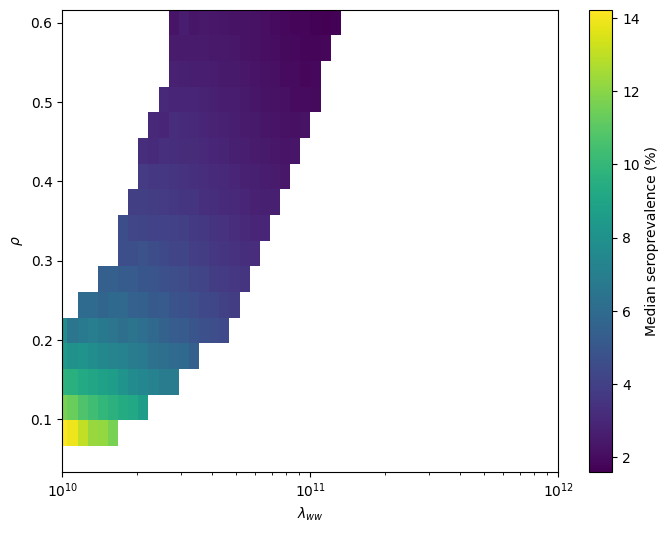

In [67]:
mask = median_matrix_both_mask > -3350   # True where valid, False where clipped
sero_masked = np.where(mask, mean_ll_array_sero_replot, np.nan)

# --- sort ρ and match the matrix -------------------------------------------
rho_sorted_idx  = np.argsort(rho_value)
rho_sorted      = np.array(rho_value)[rho_sorted_idx]
seroprev_sorted = sero_masked[:, rho_sorted_idx]

# Build grids
LambdaGrid, RhoGrid = np.meshgrid(lambda_value, rho_sorted, indexing="xy")

# --- Plot -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 6))

threshold = 5.148 - 2.996

hm = ax.pcolormesh(
    LambdaGrid, RhoGrid,
    seroprev_sorted.T,               # [ρ, λ]
    cmap="viridis", shading="auto"
)


ax.set_xscale("log")
ax.set_xlim(min(lambda_value), max(lambda_value))
ax.set_xlabel(r"$\lambda_{ww}$")
ax.set_ylabel(r"$\rho$")
fig.colorbar(hm, ax=ax, label="Median seroprevalence (%)")

plt.show()

/var/folders/v6/xf9_4qmx6773k7fg_d6nrj1r0000gn/T/ipykernel_73452/2921549521.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap("viridis")


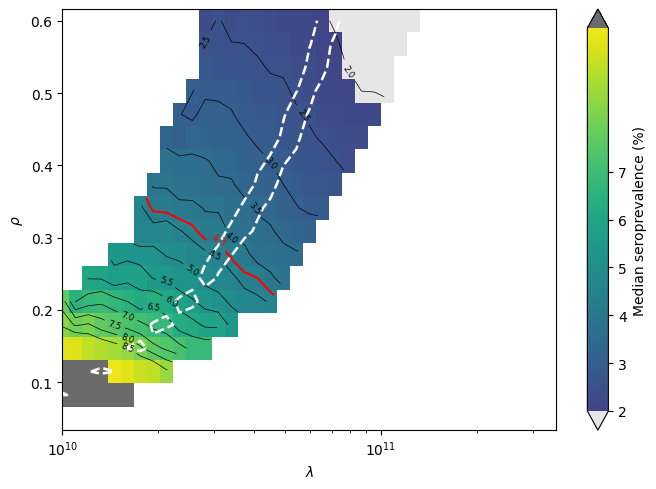

In [68]:
# --- Confidence interval contour from log-likelihood -----------------------
Lmax      = mean_ll_array_both_replot.max()
threshold = Lmax - 2.996   # 95% CI threshold

RhoGrid_like, LambdaGrid_like = np.meshgrid(rho_value, lambda_value, indexing="xy")

fig, ax = plt.subplots(figsize=(7, 5))

base = cm.get_cmap("viridis")
cmap = colors.LinearSegmentedColormap.from_list(
    "viridis_focus", base(np.linspace(0.20, 0.98, 256))
)
cmap.set_under("#e6e6e6")
cmap.set_over("#6b6b6b")
norm = colors.Normalize(vmin=2, vmax=10, clip=False)

hm = ax.pcolormesh(
    LambdaGrid, RhoGrid,
    seroprev_sorted.T,
    cmap=cmap, norm=norm, shading="nearest", rasterized=True
)

ax.set_xscale("log")
ax.set_xlim(min(lambda_value), lambda_value[-12])
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\rho$")

# Contours for seroprevalence
levels = np.arange(2, 9, 0.5)
cs = ax.contour(LambdaGrid, RhoGrid, seroprev_sorted.T,
                levels=levels, colors="k", linewidths=0.5)
ax.clabel(cs, fmt="%.1f", fontsize=6, inline=True)

# 🔴 Special contour at 4.3
cs_special = ax.contour(LambdaGrid, RhoGrid, seroprev_sorted.T,
                        levels=[4.3], colors="red", linewidths=1.5)
ax.clabel(cs_special, fmt="4.3", fontsize=7, inline=True)

# ⚪ Overlay CI contour from likelihood surface
cs_CI = ax.contour(LambdaGrid_like, RhoGrid_like,
                   mean_ll_array_both_replot,
                   levels=[threshold], colors="white", linestyles="--",
                   linewidths=1.8)
# ax.scatter(3.08884360e+10, 0.27647059, s=50, color = "red", marker='o')
#  0.27647059, 0.30882353, 0.34117647
# 3.08884360e+10, 3.39322177e+10, 3.72759372e+10, 4.09491506e+10, 4.49843267e+10
# Colorbar
cbar = fig.colorbar(hm, ax=ax, extend="both", ticks=np.arange(2, 8, 1))
cbar.set_label("Median seroprevalence (%)")

plt.tight_layout()
plt.show()


### Figure 9


In [69]:
epiparam = {
    "n": 40,  # Number of compartments 
    "sigma_Re": 0.32,  # Initial standard deviation for Brownian motion
    "lambda_ww": 65512855685,  # Shedding load scaling constant
    "delta_ww":1, # Decay rate of viral load in wastewater
    "std_ww":2.2114e12, # Sd in ww
    "k_overdispersion_case" : 10, # Overdispersion parameter for weekly incidence 
    "eps_ww_out": 0.95,  # Environmental noise factor 
    "nu": 1/40,  # Transition rate 1 per day
    "dt": dt_real,  # Time step
    "time_start_day": 0,  # Start day
    "time_end_day": 140,  # End day
    "tList": np.arange(0, 140, dt_real), #
    "rho": 0.5676470588235294 # Reporting rate (fraction of actual infections reported)
}


In [70]:
def get_logL_Joint_rho_pred(Casedata, WWdata, n_particles, epiparams, forwardday, seed=None):
    ep = copy.deepcopy(epiparams)
    ep["time_end_day"] = ep["time_end_day"] + forwardday
    ep["tList"] = np.arange(0, ep["time_end_day"], dt_real)

    rng = np.random.default_rng(seed)

    ref_date = datetime(2020, 9, 1)
    Re_curr = rng.lognormal(mean=0.0, sigma=0.5, size=(n_particles, 1))
    mu, sigma = 2.5, 1.0
    log10_I_init = rng.normal(loc=mu, scale=sigma, size=n_particles)
    I_init_total = 10**log10_I_init

    I_curr = np.zeros((n_particles, n))
    I_curr[:, 0] = I_init_total

    Sc_curr = np.zeros(n_particles)
    Sw_curr = np.zeros(n_particles)

    Re, w_list, wmean = [], [], []
    cumulative_incidence_record, wastewater_concentration_record, I_record = [], [], []

    n_timepts = len(ep["tList"])
    t_day = []

    ancestry = np.empty((n_timepts, n_particles), dtype=int)
    ancestry[:, :] = np.arange(n_particles)

    date_c_list = Casedata["date_c"].tolist()
    date_w_list = WWdata["date_w"].tolist()
    joint_list = set(date_c_list) | set(date_w_list)

    for t_idx in range(n_timepts - 1):
        current_dt = ref_date + timedelta(days=ep["tList"][t_idx])
        wd = current_dt.weekday() + 1
        rho_t = ep["rho"] if wd <= 5 else med_w_diff * ep["rho"]

        dRe = ep["sigma_Re"] * rng.standard_normal(size=(n_particles, 1)) * dt_real
        Re_curr = np.clip(Re_curr + dRe, 0, 30)

        dt = ep["tList"][t_idx + 1] - ep["tList"][t_idx]

        Psi = ep["n"] * ep["nu"] * Re_curr.flatten() * (I_curr[:, :ep["n"]] @ f_i)

        dI = np.zeros_like(I_curr)
        dI[:, 0] = Psi - ep["n"] * ep["nu"] * I_curr[:, 0]
        dI[:, 1:ep["n"]-1] = -ep["n"] * ep["nu"] * I_curr[:, 1:ep["n"]-1] + ep["n"] * ep["nu"] * I_curr[:, :ep["n"]-2]
        dI[:, ep["n"]-1] = ep["n"] * ep["nu"] * I_curr[:, ep["n"]-2]
        dSc = ep["n"] * ep["nu"] * rho_t * (I_curr[:, :ep["n"]] @ c_i)

        dSw = ep["lambda_ww"] * (I_curr[:, :ep["n"]] @ omega_i) - ep["delta_ww"] * Sw_curr
        dSw_nout = ep["eps_ww_out"] * ep["delta_ww"] * Sw_curr * rng.standard_normal(n_particles)

        I_curr[:, :ep["n"]] += dI[:, :ep["n"]] * dt
        Sc_curr += dSc * dt
        Sw_curr += dSw * dt + dSw_nout * dt

        cumulative_incidence_record.append(Sc_curr.copy())
        wastewater_concentration_record.append(Sw_curr.copy())
        I_record.append(I_curr.copy())
        Re.append(Re_curr.copy())

        compare_time = ep["tList"][t_idx + 1]

        if compare_time in joint_list:
            likelihoods = np.ones(n_particles)

            if compare_time in date_w_list:
                Sw_curr_flat = np.asarray(Sw_curr).flatten()
                obsWW = WWdata["noisy_w_values"][WWdata["date_w"] == compare_time]
                Sw_safe = np.maximum(Sw_curr_flat, np.finfo(float).tiny)

                likelihoods_ww = stats.gamma.pdf(
                    obsWW,
                    a=(Sw_safe / ep["std_ww"]) ** 2,
                    scale=(ep["std_ww"] ** 2) / Sw_safe
                )
                likelihoods *= np.ravel(likelihoods_ww)

            if compare_time in date_c_list:
                steps_back = int(1 / dt_real)
                if len(cumulative_incidence_record) > steps_back:
                    current_idx = len(cumulative_incidence_record) - 1
                    week_idx = current_idx - steps_back
                    weekly_incidence = np.zeros(n_particles)

                    for particle in range(n_particles):
                        anc = particle
                        for t in range(current_idx, week_idx, -1):
                            anc = ancestry[t, anc]
                        weekly_incidence[particle] = (
                            cumulative_incidence_record[current_idx][particle]
                            - cumulative_incidence_record[week_idx][anc]
                        )
                else:
                    weekly_incidence = cumulative_incidence_record[-1]

                weekly_incidence = np.maximum(np.asarray(weekly_incidence).flatten(), 0.0)

                obsCase = Casedata["noisy_c_values"][Casedata["date_c"] == compare_time]
                likelihoods_case = stats.nbinom.pmf(
                    obsCase,
                    ep["k_overdispersion_case"],
                    ep["k_overdispersion_case"] / (ep["k_overdispersion_case"] + weekly_incidence)
                )
                likelihoods *= np.ravel(likelihoods_case)

            # Resample
            if np.isnan(likelihoods).any():
                print("Warning: NaN values detected in likelihoods!")
                likelihoods = np.nan_to_num(likelihoods, nan=0.0, posinf=0.0, neginf=0.0)

            k_vector = util.resample_particles_multinomial(likelihoods, n_particles)
            ancestry[t_idx + 1, :] = k_vector
            I_curr = I_curr[k_vector, :]
            Sc_curr = Sc_curr[k_vector]
            Sw_curr = Sw_curr[k_vector]
            Re_curr = Re_curr[k_vector]

            t_day.append(compare_time)
            w_list.append(likelihoods)
            wmean.append(np.mean(likelihoods))

    theta_logL = np.sum(np.log(np.maximum(wmean, np.finfo(float).tiny)))

    # ---- SINGLE trajectory draw per PF run ----
    terminal_particle = rng.choice(n_particles, size=1, replace=False)

    trajectory_indices = np.empty((n_timepts, 1), dtype=int)
    trajectory_indices[-1, :] = terminal_particle
    for t in range(n_timepts - 1, 0, -1):
        trajectory_indices[t-1, :] = ancestry[t, trajectory_indices[t, :]]

    recon = {
        "Re": np.stack([Re[t][trajectory_indices[t, :]] for t in range(len(Re))]),   # (T-1, 1, 1)
        "t_day": np.array(t_day),
        "t": ep["tList"][1:],                                                        # length T-1
        "I_record": np.stack([I_record[t][trajectory_indices[t, :], :] for t in range(len(I_record))]),
        "Cumulative": np.stack([cumulative_incidence_record[t][trajectory_indices[t, :]]
                                for t in range(len(cumulative_incidence_record))]),
        "WW_concentration": np.stack([wastewater_concentration_record[t][trajectory_indices[t, :]]
                                      for t in range(len(wastewater_concentration_record))]),
    }

    d_incidence = np.diff(recon["Cumulative"], axis=0)  # (T-2, 1)

    recon["d_incidence"], recon["daily_time"] = util.block_sum(d_incidence, 10)
    recon["w_incidence"], recon["weekly_time"] = util.block_sum(d_incidence, 70)

    return theta_logL, recon



In [71]:
n_runs = 10
base_seed = 20260104  # any int you like

theta_list = []
recon_list = []

for r in range(n_runs):
    theta_r, recon_r = get_logL_Joint_rho_pred(
        ZH_case_selected, ZH_ww_selected,
        n_particles,
        epiparams=epiparam,
        forwardday=10,
        seed=base_seed + r
    )
    theta_list.append(theta_r)
    recon_list.append(recon_r)

# Stack runs along "draw" dimension (axis=1)
recon_all = {
    "t": recon_list[0]["t"],
    "daily_time": recon_list[0]["daily_time"],
    "weekly_time": recon_list[0]["weekly_time"],
    "Re": np.concatenate([rr["Re"].squeeze(-1) for rr in recon_list], axis=1),  # (T-1, 10)
    "Cumulative": np.concatenate([rr["Cumulative"] for rr in recon_list], axis=1),  # (T-1, 10)
    "WW_concentration": np.concatenate([rr["WW_concentration"] for rr in recon_list], axis=1),  # (T-1,10)
    "d_incidence": np.concatenate([rr["d_incidence"] for rr in recon_list], axis=1),  # (T_daily,10)
    "w_incidence": np.concatenate([rr["w_incidence"] for rr in recon_list], axis=1),  # (T_weekly,10)
}

# If you want a single logL summary for the 10-run ensemble:
theta_logL_mean = float(np.mean(theta_list))
theta_logL_median = float(np.median(theta_list))

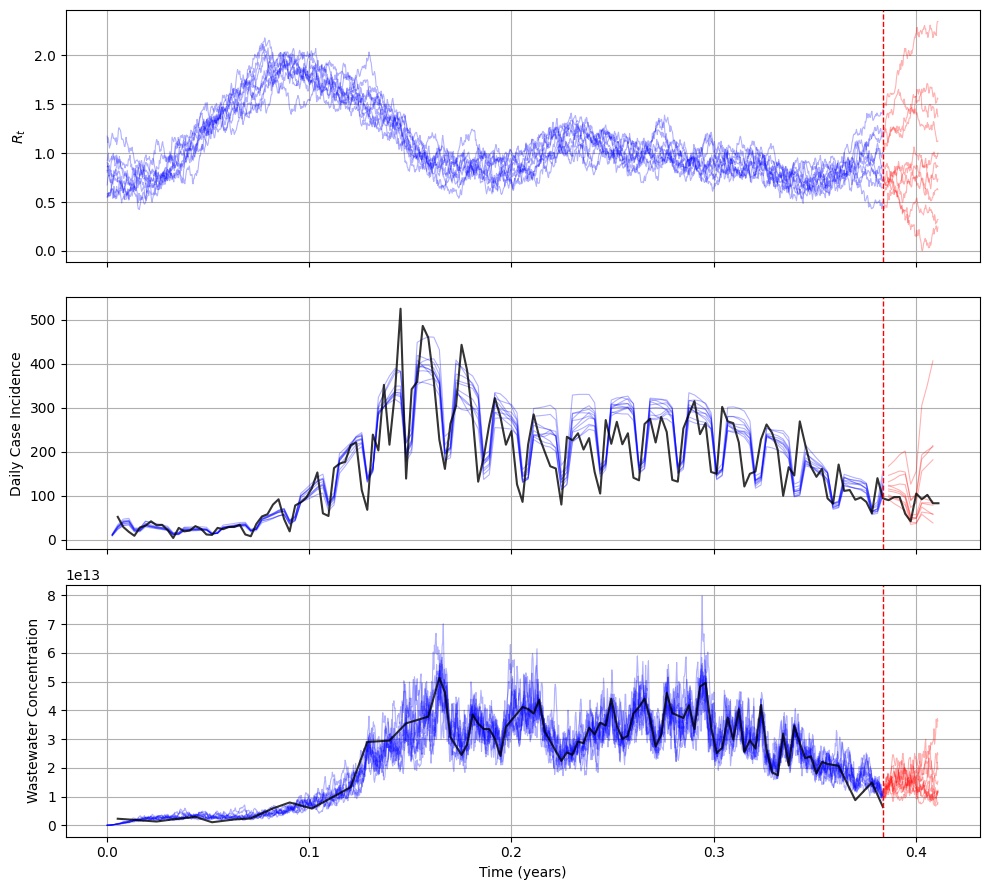

In [72]:
def align_time_series(time_vec, series_2d):
    """
    time_vec: (T,) array-like
    series_2d: (T2, n_draws) array-like
    Returns time_vec_aligned, series_2d_aligned with matched first dimension.
    """
    time_vec = np.asarray(time_vec).flatten()
    series_2d = np.asarray(series_2d)
    if series_2d.ndim == 1:
        series_2d = series_2d[:, None]

    n = min(len(time_vec), series_2d.shape[0])
    return time_vec[:n], series_2d[:n, :]


# Align daily
recon_all["daily_time"], recon_all["d_incidence"] = align_time_series(
    recon_all["daily_time"], recon_all["d_incidence"]
)

# Align continuous-time series (Re and WW) with t
recon_all["t"], recon_all["Re"] = align_time_series(recon_all["t"], recon_all["Re"])
# WW_concentration should match t as well
_, recon_all["WW_concentration"] = align_time_series(recon_all["t"], recon_all["WW_concentration"])


# -----------------------------
# Plot settings
# -----------------------------
n_runs
cut_day = 140                        # your cutoff in "model days"
cut_x = cut_day / 365

fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# -----------------------------
# Panel 1: R_t trajectories
# -----------------------------
t_year = recon_all["t"] / 365
mask_pre = recon_all["t"] <= cut_day
mask_post = recon_all["t"] > cut_day

for j in range(n_runs):
    axs[0].plot(t_year[mask_pre],  recon_all["Re"][:, j][mask_pre],  alpha=0.3, linewidth=0.8, color="blue")
    axs[0].plot(t_year[mask_post], recon_all["Re"][:, j][mask_post], alpha=0.3, linewidth=0.8, color="red")

axs[0].axvline(cut_x, color="red", linestyle="--", linewidth=1.0)
axs[0].set_ylabel(r"$R_t$")
axs[0].grid(True)


# -----------------------------
# Panel 2: Daily incidence trajectories + observed
# -----------------------------
daily_year = recon_all["daily_time"] / 365
mask_pre_d = recon_all["daily_time"] <= cut_day
mask_post_d = recon_all["daily_time"] > cut_day

for j in range(n_runs):
    axs[1].plot(daily_year[mask_pre_d],  recon_all["d_incidence"][:, j][mask_pre_d],
                alpha=0.3, linewidth=0.8, color="blue")
    axs[1].plot(daily_year[mask_post_d], recon_all["d_incidence"][:, j][mask_post_d],
                alpha=0.3, linewidth=0.8, color="red")

# observed daily incidence (your existing series)
axs[1].plot(ZH_case_future["date_c"]/365,
            ZH_case_future["noisy_c_values"],
            linestyle="-", color="black", label="Daily Incidence Data", alpha=0.8)

axs[1].axvline(cut_x, color="red", linestyle="--", linewidth=1.0)
axs[1].set_ylabel("Daily Case Incidence")
axs[1].grid(True)

# -----------------------------
# Panel 3: Wastewater trajectories + observed
# -----------------------------
mask_pre_w = recon_all["t"] <= cut_day
mask_post_w = recon_all["t"] > cut_day

for j in range(n_runs):
    axs[2].plot(t_year[mask_pre_w],  recon_all["WW_concentration"][:, j][mask_pre_w],
                alpha=0.3, linewidth=0.8, color="blue")
    axs[2].plot(t_year[mask_post_w], recon_all["WW_concentration"][:, j][mask_post_w],
                alpha=0.3, linewidth=0.8, color="red")

axs[2].plot(ZH_ww_selected["date_w"]/365,
            ZH_ww_selected["noisy_w_values"],
            linestyle="-", color="black", label="Wastewater Data", alpha=0.8)

axs[2].axvline(cut_x, color="red", linestyle="--", linewidth=1.0)

axs[2].set_ylabel("Wastewater Concentration")
axs[2].set_xlabel("Time (years)")
axs[2].grid(True)


plt.tight_layout()
plt.show()


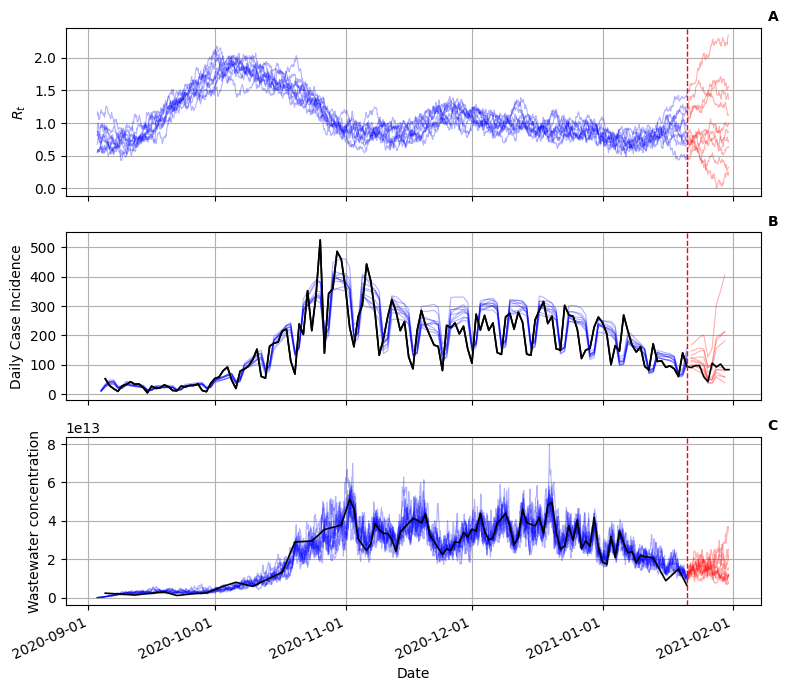

In [73]:

# Continuous time (Rt, WW)
date_t = np.array([start_date + timedelta(days=float(ti)) for ti in recon_all["t"]])

# Daily incidence
date_daily = np.array([start_date + timedelta(days=float(ti)) for ti in recon_all["daily_time"]])

# Observations
date_obs = ZH_case_selected["date_c"].apply(lambda d: start_date + timedelta(days=float(d)))
date_future = ZH_case_future["date_c"].apply(lambda d: start_date + timedelta(days=float(d)))

cutoff_date = start_date + timedelta(days=cut_day)

date_locator = mdates.AutoDateLocator()
date_formatter = mdates.DateFormatter("%Y-%m-%d")


fig, axs = plt.subplots(3, 1, figsize=(8, 7), sharex=True)

# ============================
# Panel 1: R_t
# ============================
mask_pre = date_t <= cutoff_date
mask_post = date_t > cutoff_date

for j in range(10):
    axs[0].plot(date_t[mask_pre],  recon_all["Re"][:, j][mask_pre],
                color="blue", alpha=0.3, linewidth=0.8)
    axs[0].plot(date_t[mask_post], recon_all["Re"][:, j][mask_post],
                color="red", alpha=0.3, linewidth=0.8)

axs[0].axvline(cutoff_date, color="red", linestyle="--", linewidth=1)
axs[0].set_ylabel(r"$R_t$")
axs[0].grid(True)
axs[0].text(1.01, 1.04, 'A', transform=axs[0].transAxes, fontweight="bold")


# ============================
# Panel 2: Daily incidence
# ============================
mask_pre_d = date_daily <= cutoff_date
mask_post_d = date_daily > cutoff_date

for j in range(n_runs):
    axs[1].plot(date_daily[mask_pre_d],  recon_all["d_incidence"][:, j][mask_pre_d],
                color="blue", alpha=0.3, linewidth=0.8)
    axs[1].plot(date_daily[mask_post_d], recon_all["d_incidence"][:, j][mask_post_d],
                color="red", alpha=0.3, linewidth=0.8)

axs[1].plot(date_obs,
            ZH_case_selected["noisy_c_values"],
            color="black", linewidth=1.2, label="Observed cases")

axs[1].plot(date_future,
            ZH_case_future["noisy_c_values"],
            color="black", linewidth=1.2, label="Future cases")

axs[1].axvline(cutoff_date, color="red", linestyle="--", linewidth=1)
axs[1].set_ylabel("Daily Case Incidence")
axs[1].grid(True)
axs[1].text(1.01, 1.04, 'B', transform=axs[1].transAxes, fontweight="bold")


# ============================
# Panel 3: Wastewater
# ============================
for j in range(n_runs):
    axs[2].plot(date_t[mask_pre],  recon_all["WW_concentration"][:, j][mask_pre],
                color="blue", alpha=0.3, linewidth=0.8)
    axs[2].plot(date_t[mask_post], recon_all["WW_concentration"][:, j][mask_post],
                color="red", alpha=0.3, linewidth=0.8)

axs[2].plot(
    ZH_ww_selected["date_w"].apply(lambda d: start_date + timedelta(days=float(d))),
    ZH_ww_selected["noisy_w_values"],
    color="black", linewidth=1.2, label="Observed wastewater"
)

axs[2].axvline(cutoff_date, color="red", linestyle="--", linewidth=1)
axs[2].set_ylabel("Wastewater concentration")
axs[2].set_xlabel("Date")
axs[2].text(1.01, 1.04, 'C', transform=axs[2].transAxes, fontweight="bold")
axs[2].grid(True)



# ============================
# Apply date formatting
# ============================
axs[2].xaxis.set_major_locator(date_locator)
axs[2].xaxis.set_major_formatter(date_formatter)
fig.autofmt_xdate(rotation=25)

plt.tight_layout()
plt.show()
